<a href="https://colab.research.google.com/github/LGNLogAN/Wed_2026_bigdatacomputing/blob/main/life_expectancy_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WHO 기대수명 예측 머신러닝 과제

다중 특성 회귀 모델 파이프라인을 구축하고 Streamlit 웹앱으로 배포하는 Colab용 노트북입니다.

## 1. 라이브러리 설치

In [ ]:
!pip install streamlit pyngrok joblib pandas scikit-learn matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. 라이브러리 불러오기

In [ ]:
import os
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


## 3. 데이터 로드 및 전처리

In [ ]:
# WHO 기대수명 데이터셋 URL
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"

# CSV 파일 로드
df = pd.read_csv(url)

# 컬럼명 앞뒤 공백 제거
df.columns = df.columns.str.strip()

# 원본 CSV의 Adult mortality 컬럼명을 과제 요구사항에 맞게 정리
df = df.rename(columns={"Adult mortality": "Adult Mortality"})

# 결측치 제거
df = df.dropna()

# 예측 대상 컬럼
target = "Life expectancy"

# 과제에서 지정한 5개 독립변수
# 주의: Schooling 컬럼은 독립변수로 사용하지 않는다.
features = [
    "Adult Mortality",
    "BMI",
    "GDP",
    "Alcohol",
    "Polio",
]

df[features + [target]].head()


,Adult Mortality,BMI,GDP,Alcohol,Polio,Life expectancy
0,263.0,19.1,584.259210,0.01,6.0,65.0
1,271.0,18.6,612.696514,0.01,58.0,59.9
2,268.0,18.1,631.744976,0.01,62.0,59.9
3,272.0,17.6,669.959000,0.01,67.0,59.5
4,275.0,17.2,63.537231,0.01,68.0,59.2


## 4. Train/Test 분리 및 50개 훈련 샘플 추출

In [ ]:
# 전체 데이터를 독립변수 X, 종속변수 y로 분리
X = df[features]
y = df[target]

# 전체 데이터의 80%를 훈련 데이터, 20%를 테스트 데이터로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

# 과대적합 관찰을 위해 훈련 데이터에서 50개 샘플만 추출
X_train_sample = X_train.sample(n=50, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

print("X_train_sample shape:", X_train_sample.shape)
print("X_test shape:", X_test.shape)


X_train_sample shape: (50, 5)
X_test shape: (330, 5)


## 5. 모델 3종 생성 및 학습

In [ ]:
# Model 1: Linear
linear_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("linear", LinearRegression()),
    ]
)

# Model 2: Poly, 3차 다항 회귀, 규제 없음
poly_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("linear", LinearRegression()),
    ]
)

# Model 3: Ridge, 3차 다항 회귀 + Ridge 규제
ridge_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("ridge", Ridge(alpha=1.0)),
    ]
)

models = {
    "Linear": linear_model,
    "Poly": poly_model,
    "Ridge": ridge_model,
}

# 반드시 X_train_sample, y_train_sample로 학습
for name, model in models.items():
    model.fit(X_train_sample, y_train_sample)
    print(f"{name} 모델 학습 완료")


Linear 모델 학습 완료
Poly 모델 학습 완료
Ridge 모델 학습 완료


## 6. 모델 저장

In [ ]:
# 학습된 모델을 pkl 파일로 저장
joblib.dump(linear_model, "linear_model.pkl")
joblib.dump(poly_model, "poly_model.pkl")
joblib.dump(ridge_model, "ridge_model.pkl")

print("모델 저장 완료")


모델 저장 완료


## 7. 성능 비교 테이블

In [ ]:
def get_complexity(model, model_name):
    """모델이 최종적으로 사용하는 특성 개수를 계산한다."""
    if model_name == "Linear":
        return len(features)

    scaled_sample = model.named_steps["scaler"].transform(X_train_sample.iloc[:1])
    poly = model.named_steps["poly"]
    return poly.transform(scaled_sample).shape[1]


results = []

for name, model in models.items():
    train_pred = model.predict(X_train_sample)
    test_pred = model.predict(X_test)

    results.append(
        {
            "Model": name,
            "Train R2": r2_score(y_train_sample, train_pred),
            "Test R2": r2_score(y_test, test_pred),
            "Train MSE": mean_squared_error(y_train_sample, train_pred),
            "Test MSE": mean_squared_error(y_test, test_pred),
            "Complexity": get_complexity(model, name),
        }
    )

result_df = pd.DataFrame(results)
result_df


,Model,Train R2,Test R2,Train MSE,Test MSE,Complexity
0,Linear,0.733740,0.583211,2.919930e+01,29.601389,5
1,Poly,1.000000,-770.074437,9.798738e-26,54763.622231,55
2,Ridge,0.953628,0.364305,5.085425e+00,45.148646,55


## 8. Test R2 비교 그래프

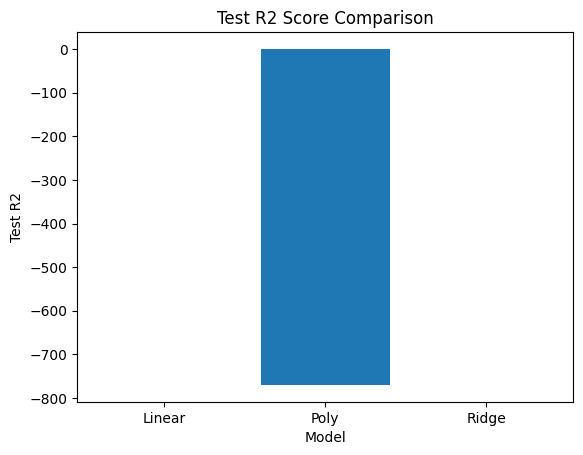

In [ ]:
fig, ax = plt.subplots()
ax.bar(result_df["Model"], result_df["Test R2"])
ax.set_xlabel("Model")
ax.set_ylabel("Test R2")
ax.set_title("Test R2 Score Comparison")
plt.show()


## 9. Streamlit app.py 파일 생성

In [ ]:
%%writefile app.py
import os

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import streamlit as st
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


# WHO 기대수명 데이터셋 URL
DATA_URL = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"

# 예측 대상 컬럼
TARGET = "Life expectancy"

# 과제에서 지정한 5개 독립변수
# 주의: Schooling 컬럼은 독립변수로 사용하지 않는다.
FEATURES = [
    "Adult Mortality",
    "BMI",
    "GDP",
    "Alcohol",
    "Polio",
]

MODEL_FILES = {
    "Linear": "linear_model.pkl",
    "Poly": "poly_model.pkl",
    "Ridge": "ridge_model.pkl",
}


@st.cache_data
def load_data():
    """데이터를 불러오고 컬럼명 정리 및 결측치 제거를 수행한다."""
    df = pd.read_csv(DATA_URL)
    df.columns = df.columns.str.strip()
    df = df.rename(columns={"Adult mortality": "Adult Mortality"})
    df = df.dropna()
    return df


@st.cache_data
def prepare_data(df):
    """독립변수/종속변수 분리, train/test split, 훈련 샘플 50개 추출을 수행한다."""
    X = df[FEATURES]
    y = df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
    )

    # 과대적합 관찰을 위해 전체 훈련 데이터가 아니라 50개 샘플만 사용한다.
    X_train_sample = X_train.sample(n=50, random_state=42)
    y_train_sample = y_train.loc[X_train_sample.index]

    return X_train_sample, X_test, y_train_sample, y_test


def build_models():
    """과제 요구사항에 맞는 3개 파이프라인 모델을 생성한다."""
    linear_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("linear", LinearRegression()),
        ]
    )

    poly_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=3, include_bias=False)),
            ("linear", LinearRegression()),
        ]
    )

    ridge_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=3, include_bias=False)),
            ("ridge", Ridge(alpha=1.0)),
        ]
    )

    return {
        "Linear": linear_model,
        "Poly": poly_model,
        "Ridge": ridge_model,
    }


def train_and_save_models(X_train_sample, y_train_sample):
    """모델을 50개 훈련 샘플로 학습한 뒤 pkl 파일로 저장한다."""
    models = build_models()

    for model_name, model in models.items():
        model.fit(X_train_sample, y_train_sample)
        joblib.dump(model, MODEL_FILES[model_name])

    return models


def load_or_train_models(X_train_sample, y_train_sample):
    """pkl 파일이 있으면 로드하고, 없으면 학습 후 저장한다."""
    if all(os.path.exists(path) for path in MODEL_FILES.values()):
        return {
            model_name: joblib.load(path)
            for model_name, path in MODEL_FILES.items()
        }

    return train_and_save_models(X_train_sample, y_train_sample)


def get_complexity(model, model_name, X_train_sample):
    """모델이 최종적으로 사용하는 특성 개수를 계산한다."""
    if model_name == "Linear":
        return len(FEATURES)

    scaled_sample = model.named_steps["scaler"].transform(X_train_sample.iloc[:1])
    poly = model.named_steps["poly"]
    return poly.transform(scaled_sample).shape[1]


def evaluate_models(models, X_train_sample, X_test, y_train_sample, y_test):
    """Train/Test R2, MSE, Complexity를 계산해 DataFrame으로 반환한다."""
    results = []

    for model_name, model in models.items():
        train_pred = model.predict(X_train_sample)
        test_pred = model.predict(X_test)

        results.append(
            {
                "Model": model_name,
                "Train R2": r2_score(y_train_sample, train_pred),
                "Test R2": r2_score(y_test, test_pred),
                "Train MSE": mean_squared_error(y_train_sample, train_pred),
                "Test MSE": mean_squared_error(y_test, test_pred),
                "Complexity": get_complexity(model, model_name, X_train_sample),
            }
        )

    result_df = pd.DataFrame(results)
    return result_df


def make_sidebar_inputs(df):
    """5개 특성에 대한 Streamlit 사이드바 슬라이더를 생성한다."""
    st.sidebar.header("입력값 설정")

    adult_mortality = st.sidebar.slider(
        "Adult Mortality",
        float(df["Adult Mortality"].min()),
        float(df["Adult Mortality"].max()),
        float(df["Adult Mortality"].mean()),
    )

    bmi = st.sidebar.slider(
        "BMI",
        float(df["BMI"].min()),
        float(df["BMI"].max()),
        float(df["BMI"].mean()),
    )

    gdp = st.sidebar.slider(
        "GDP",
        float(df["GDP"].min()),
        float(df["GDP"].max()),
        float(df["GDP"].mean()),
    )

    alcohol = st.sidebar.slider(
        "Alcohol",
        float(df["Alcohol"].min()),
        float(df["Alcohol"].max()),
        float(df["Alcohol"].mean()),
    )

    polio = st.sidebar.slider(
        "Polio",
        float(df["Polio"].min()),
        float(df["Polio"].max()),
        float(df["Polio"].mean()),
    )

    input_data = pd.DataFrame(
        [
            {
                "Adult Mortality": adult_mortality,
                "BMI": bmi,
                "GDP": gdp,
                "Alcohol": alcohol,
                "Polio": polio,
            }
        ]
    )

    return input_data


def main():
    st.title("WHO 기대수명 예측 웹 서비스")

    df = load_data()
    X_train_sample, X_test, y_train_sample, y_test = prepare_data(df)
    models = load_or_train_models(X_train_sample, y_train_sample)
    result_df = evaluate_models(
        models,
        X_train_sample,
        X_test,
        y_train_sample,
        y_test,
    )

    input_data = make_sidebar_inputs(df)

    model_choice = st.selectbox(
        "사용할 모델을 선택하세요",
        ["Linear", "Poly", "Ridge"],
    )

    selected_model = models[model_choice]
    prediction = selected_model.predict(input_data)[0]

    st.metric("예측 기대수명", f"{prediction:.2f} 세")

    st.subheader("모델 성능 비교")
    st.dataframe(
        result_df.style.format(
            {
                "Train R2": "{:.4f}",
                "Test R2": "{:.4f}",
                "Train MSE": "{:.4f}",
                "Test MSE": "{:.4f}",
            }
        ),
        use_container_width=True,
    )

    st.subheader("Test R2 Score Comparison")
    fig, ax = plt.subplots()
    ax.bar(result_df["Model"], result_df["Test R2"])
    ax.set_xlabel("Model")
    ax.set_ylabel("Test R2")
    ax.set_title("Test R2 Score Comparison")
    st.pyplot(fig)

    st.subheader("입력 데이터")
    st.dataframe(input_data, use_container_width=True)


if __name__ == "__main__":
    main()


Writing app.py


## 10. Colab에서 Streamlit 실행

In [ ]:
# Streamlit 앱 실행
!streamlit run app.py --server.port 8501 &




2026-06-17 09:37:29.449 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.44.18:8501



## 11. ngrok 연결

In [ ]:
from pyngrok import ngrok

# ngrok authtoken이 필요한 경우 아래 주석을 해제하고 본인 토큰을 입력합니다.
# !ngrok config add-authtoken "본인_ngrok_authtoken"

public_url = ngrok.connect(8501)
print(public_url)


## 12. 제출 파일 구조

GitHub에는 아래 파일을 업로드합니다. 결과 화면 캡처는 이 노트북에 첨부합니다.

```text
life_expectancy_assignment.ipynb
app.py
linear_model.pkl
poly_model.pkl
ridge_model.pkl
README.md
```